In [1]:
import numpy as np
import imageio as imio
import os
import torch


import tqdm
import cv2
import matplotlib.pyplot as plt
from utils import *

/home/ituarc/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:500: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:500: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(sel

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def warp_corners_and_draw_matches(ref_points, dst_points, img1, img2):
    # Calculate the Homography matrix
    # H, mask = cv2.findHomography(ref_points, dst_points, cv2.USAC_MAGSAC, 3.5, maxIters=1_000, confidence=0.999)
    # mask = mask.flatten()



    # OpenCV expects points as (x, y) float32
    src_pts = np.array(ref_points, dtype=np.float32).reshape(-1, 1, 2)
    dst_pts = np.array(dst_points, dtype=np.float32).reshape(-1, 1, 2)

    # For 'similarity', we can use estimateAffinePartial2D
    _, mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC,
                                                 ransacReprojThreshold=5)   # NOTE: CHECK SPEED OF RANSAC
    
    mask = mask.flatten().astype(bool)

    print('inlier ratio: ', np.sum(mask)/len(mask))
    print('num inliers: ', np.sum(mask))
    
    

    # # Get corners of the first image (image1)
    # h, w = img1.shape[:2]
    # corners_img1 = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32).reshape(-1, 1, 2)

    # # Warp corners to the second image (image2) space
    # warped_corners = cv2.perspectiveTransform(corners_img1, H)

    # # Draw the warped corners in image2
    # img2_with_corners = img2.copy()
    # for i in range(len(warped_corners)):
    #     start_point = tuple(warped_corners[i-1][0].astype(int))
    #     end_point = tuple(warped_corners[i][0].astype(int))
    #     cv2.line(img2_with_corners, start_point, end_point, (0, 255, 0), 4)  # Using solid green for corners

    # Prepare keypoints and matches for drawMatches function
    keypoints1 = [cv2.KeyPoint(p[0], p[1], 5) for p in ref_points]
    keypoints2 = [cv2.KeyPoint(p[0], p[1], 5) for p in dst_points]
    matches = [cv2.DMatch(i,i,0) for i in range(len(mask)) if mask[i]]

    # Draw inlier matches
    img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches, None,
                                  matchColor=(0, 255, 0), flags=2)

    return img_matches

In [3]:
def findInlier(src_points, dst_points, ransacReprojThreshold=5.0):
    """
    Rough Python approximation of MATLAB's 'estgeotform2d(...,"similarity")'.
    Uses OpenCV's estimateAffinePartial2D or estimateAffine2D as an analogy.
    Returns (matrix, inlierMask, _) to mimic (tform, inlierIdx, status).
    Here, inlierMask is a boolean array marking inliers.
    """
    # if len(src_points) < 3 or len(dst_points) < 3:
    #     # Not enough points to estimate a transform
    #     return np.array([], dtype=bool)

    # OpenCV expects points as (x, y) float32
    src_pts = np.array(src_points, dtype=np.float32).reshape(-1, 1, 2)
    dst_pts = np.array(dst_points, dtype=np.float32).reshape(-1, 1, 2)

    # For 'similarity', we can use estimateAffinePartial2D
    _, inlier_mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC,
                                                 ransacReprojThreshold=ransacReprojThreshold)   # NOTE: CHECK SPEED OF RANSAC
    if inlier_mask is None:
        return np.array([], dtype=bool)

    inlier_mask = inlier_mask.ravel().astype(bool)
    return inlier_mask

In [4]:
xfeat = torch.hub.load('verlab/accelerated_features', 'XFeat', pretrained = True, top_k = 1300)


Using cache found in /home/ituarc/.cache/torch/hub/verlab_accelerated_features_main
/home/ituarc/.local/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [14]:
from utils import resize_image


#Load some example images
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0038_20251018_211205.jpg"
image0 = "/home/ituarc/Documents/GitHub/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0054_20251018_211221.jpg"
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0025_20251018_211152.jpg"
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0038_20251018_211205.jpg"
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0041_20251018_211208.jpg"
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0052_20251018_211219.jpg
# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/256/frame_0058_20251018_205641.jpg"

# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/256/frame_0054_20251018_205637.jpg"
# image1 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0042_20251018_211209.jpg"

# image0 = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/satellite/540/bacikoy_sat (1).jpg"


# image0 =  "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/satellite/1400/bacikoy_sat (1).jpg"

image1 = "/home/ituarc/Documents/GitHub/FeatureMatching-PythonCODE/captured_frames_bacikoy/satellite/1400/bacikoy_sat (1).jpg"
d = 300
im1_src = np.copy(imio.v2.imread(image0))
im1_src = resize_image(im1_src, (d,d))

im2_src = imio.v2.imread(image1)
im2_src = resize_image(im2_src, (d,d))

# im2_src = resize_image(im2_src, [540,540]) 

if im2_src.ndim == 2:  # grayscale -> add channel dimension
    im2 = np.copy(im2_src[..., np.newaxis])
else:  # color -> keep same handling as im1 (reverse channels)
    im2 = np.copy(im2_src[..., ::-1])
    
if im1_src.ndim == 2:  # grayscale -> add channel dimension
    im1 = np.copy(im1_src[..., np.newaxis])
else:  # color -> keep same handling as im2 (reverse channels)
    im1 = np.copy(im1_src[..., ::-1])






Loaded LightGlue model


/home/ituarc/.cache/torch/hub/verlab_accelerated_features_main/modules/lighterglue.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights, map_

inlier ratio:  0.6964285714285714
num inliers:  78


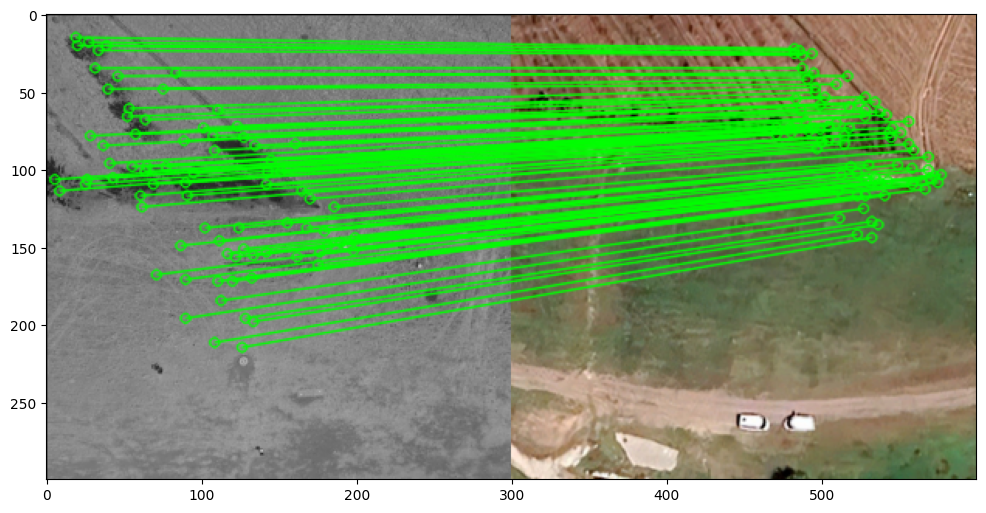

(<matplotlib.image.AxesImage at 0xfffe81c6d870>, None)

In [15]:
# Inference with batch = 1
output0 = xfeat.detectAndCompute(im1)[0]
output1 = xfeat.detectAndCompute(im2)[0]


# # im1 = im1[None, ...]
# # im2 = im2[None, ...]
# # output0 = xfeat.detectAndComputeDense(torch.tensor(im1).permute(0,3,1,2)/255, top_k = 1300)
# # output1 = xfeat.detectAndComputeDense(torch.tensor(im2).permute(0,3,1,2)/255, top_k = 1300)


# # #Update with image resolution (required)
output0.update({'image_size': (im1.shape[1], im1.shape[0])})
output1.update({'image_size': (im2.shape[1], im2.shape[0])})

# output0.update({'image_size': (torch.from_numpy(np.array([im1.shape[1], im1.shape[0]])).to('cuda'))})
# output1.update({'image_size': (torch.from_numpy(np.array([im2.shape[1], im2.shape[0]])).to('cuda'))})

matches = xfeat.match_lighterglue(output0, output1)
# matches = xfeat.match_xfeat_star(im1, im2)


# matches = xfeat.match_xfeat_star(im1,im2)

mkpts_0 = matches[0]
mkpts_1 = matches[1]


canvas = warp_corners_and_draw_matches(mkpts_0, mkpts_1, im1, im2)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()


In [17]:
# Add two dummy keypoints (and matching scores + descriptors) to output0
kp = output0['keypoints']
dev = kp.device
dtype = kp.dtype

dummy_kp = torch.tensor([[-1.0, -1.0],
                         [-1.0, -1.0]], device=dev, dtype=dtype)
output0['keypoints'] = torch.cat([kp, dummy_kp], dim=0)

if 'scores' in output0:
    sc = output0['scores']
    dummy_sc = torch.zeros((dummy_kp.shape[0],), device=dev, dtype=sc.dtype)
    output0['scores'] = torch.cat([sc, dummy_sc], dim=0)

if 'descriptors' in output0:
    desc = output0['descriptors']
    D = desc.shape[1]
    dummy_desc = torch.zeros((dummy_kp.shape[0], D), device=dev, dtype=desc.dtype)
    output0['descriptors'] = torch.cat([desc, dummy_desc], dim=0)

# show updated shapes
output0['keypoints'].shape, output0['scores'].shape, output0['descriptors'].shape

(torch.Size([1302, 2]), torch.Size([1302]), torch.Size([1302, 64]))

In [20]:
from time import time
n = 5
x2 = torch.randn(n,3,500,500)

for i in range(10):
    # torch.cuda.synchronize()
    start = time()
    for j in range(10):
        matches = xfeat.match_lighterglue(output0, output1)
        
    # output0 = xfeat.detectAndCompute(x2, top_k = 1300)[0]
    end = time()
    # torch.cuda.synchronize()

    print(f"Iteration {i}: {end - start:.4f} seconds")


Iteration 0: 1.1222 seconds
Iteration 1: 1.0887 seconds
Iteration 2: 1.3040 seconds
Iteration 3: 1.0421 seconds
Iteration 4: 1.0278 seconds
Iteration 5: 1.0182 seconds
Iteration 6: 1.0631 seconds
Iteration 7: 1.0099 seconds
Iteration 8: 1.1032 seconds
Iteration 9: 1.1793 seconds


In [19]:
output0

{'keypoints': tensor([[ 838.3721, 1226.0175],
         [ 350.0000, 1280.9594],
         [ 837.3547, 1237.2094],
         ...,
         [ 450.7267,  321.5116],
         [ 791.5698,  502.6163],
         [ 984.8837,  826.1628]], device='cuda:0'),
 'scores': tensor([0.6277, 0.5568, 0.5514,  ..., 0.1629, 0.1628, 0.1628], device='cuda:0'),
 'descriptors': tensor([[-0.0371, -0.2588, -0.0290,  ..., -0.0640, -0.0493,  0.1422],
         [-0.0775, -0.0635, -0.0591,  ..., -0.1878,  0.0094,  0.0444],
         [-0.0293, -0.2122, -0.0441,  ..., -0.0613, -0.0712,  0.1331],
         ...,
         [ 0.1370,  0.0822,  0.1258,  ...,  0.0383,  0.1390, -0.0133],
         [ 0.2707,  0.1401,  0.1262,  ..., -0.0110, -0.0415,  0.0110],
         [ 0.2157,  0.0031,  0.1135,  ..., -0.0974,  0.0859,  0.0577]],
        device='cuda:0'),
 'image_size': (1400, 1400)}

inlier ratio:  0.5


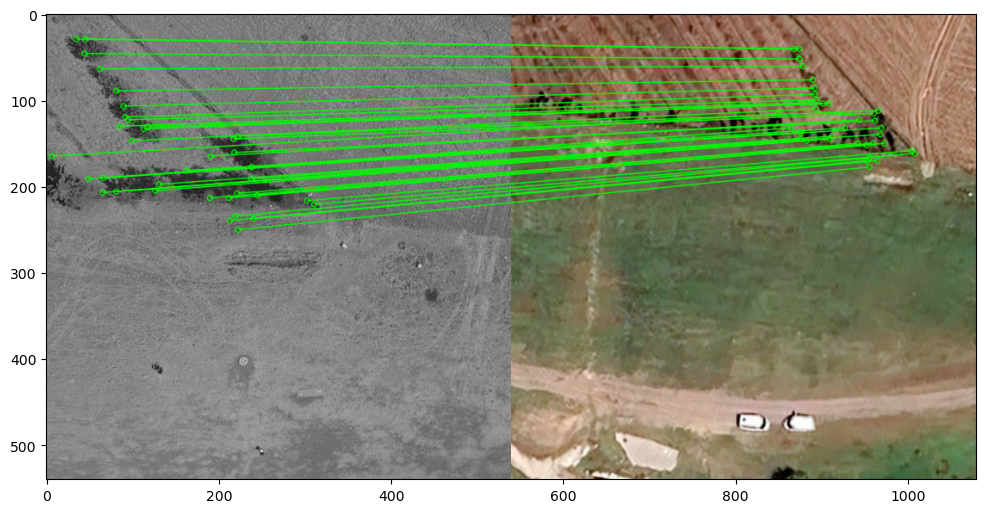

(<matplotlib.image.AxesImage at 0xfffe7c0c7ca0>, None)

In [25]:

mkpts_0 = matches[0]
mkpts_1 = matches[1]


canvas = warp_corners_and_draw_matches(mkpts_0, mkpts_1, im1, im2)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()

In [53]:


from time import time
for i in range(10):
    start = time()
    # matches_list = xfeat.match_xfeat_star(x1, x2, top_k = 512)
    for i in range(100):
        canvas = warp_corners_and_draw_matches(mkpts_0, mkpts_1, im1, im2)

    end = time()
    print(f"Iteration {i}: {end - start:.4f} seconds")


Iteration 99: 0.0420 seconds
Iteration 99: 0.0409 seconds
Iteration 99: 0.0408 seconds
Iteration 99: 0.0407 seconds
Iteration 99: 0.0407 seconds
Iteration 99: 0.0410 seconds
Iteration 99: 0.0408 seconds
Iteration 99: 0.0407 seconds
Iteration 99: 0.0407 seconds
Iteration 99: 0.0406 seconds


In [59]:
from time import time
for i in range(10):
    start = time()
    # matches_list = xfeat.match_xfeat_star(x1, x2, top_k = 512)
    for i in range(100):
        canvas = findInlier(mkpts_0, mkpts_1)

    end = time()
    print(f"Iteration {i}: {end - start:.4f} seconds")

Iteration 99: 0.0055 seconds
Iteration 99: 0.0046 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds
Iteration 99: 0.0042 seconds


In [8]:
# Create 4 image pairs
x1 = torch.randn(20,1,540,540)
x2 = torch.randn(20,1,540,540)

#Obtain matches for each batch item

matches_list = xfeat.match_xfeat_star(x1, x2, top_k = 512)
# print('number of img pairs', len(matches_list))
# print(matches_list[0].shape) # -> output is (x1,y1,x2,y2)

In [13]:
from time import time
for i in range(10):
    start = time()
    # matches_list = xfeat.match_xfeat_star(x1, x2, top_k = 512)
    matches_list = xfeat.match_xfeat(x1, x2, top_k = 512)

    end = time()
    print(f"Iteration {i}: {end - start:.4f} seconds")

Iteration 0: 0.3359 seconds
Iteration 1: 0.3529 seconds
Iteration 2: 0.3725 seconds
Iteration 3: 0.3615 seconds
Iteration 4: 0.3841 seconds
Iteration 5: 0.3957 seconds
Iteration 6: 0.3948 seconds
Iteration 7: 0.3964 seconds
Iteration 8: 0.3879 seconds
Iteration 9: 0.3849 seconds


In [65]:
output0

{'keypoints': tensor([[257.3438, 129.7266],
         [283.7109, 485.1562],
         [129.7266, 458.7891],
         ...,
         [ 92.8125, 396.5625],
         [435.5859, 348.0469],
         [ 98.0859, 142.3828]], device='cuda:0'),
 'scores': tensor([0.5212, 0.4871, 0.4663,  ..., 0.0753, 0.0753, 0.0752], device='cuda:0'),
 'descriptors': tensor([[ 0.1398, -0.1040,  0.0618,  ..., -0.1336, -0.0019, -0.0359],
         [ 0.2166,  0.0548,  0.1552,  ..., -0.0177, -0.0822,  0.0058],
         [ 0.2178,  0.2419,  0.0088,  ...,  0.0032, -0.0430, -0.0762],
         ...,
         [ 0.1233, -0.0735, -0.1417,  ..., -0.0451, -0.0636, -0.0179],
         [ 0.2185,  0.0884,  0.0950,  ..., -0.0954, -0.0047,  0.0888],
         [ 0.2688, -0.0912,  0.0623,  ...,  0.0533, -0.0139,  0.1163]],
        device='cuda:0'),
 'image_size': (540, 540)}

In [17]:
output0.keys()

dict_keys(['keypoints', 'scores', 'descriptors', 'image_size'])

In [40]:
im1

array([[[ 12,  14,  15],
        [ 12,  15,  17],
        [ 12,  15,  19],
        ...,
        [ 52,  56,  55],
        [ 55,  58,  58],
        [ 59,  62,  61]],

       [[ 12,  14,  16],
        [ 11,  14,  18],
        [ 12,  16,  22],
        ...,
        [ 61,  66,  65],
        [ 58,  63,  62],
        [ 54,  58,  57]],

       [[ 11,  14,  17],
        [ 10,  14,  18],
        [ 10,  16,  22],
        ...,
        [ 65,  71,  70],
        [ 66,  71,  70],
        [ 56,  60,  59]],

       ...,

       [[ 87, 108, 114],
        [ 86, 109, 119],
        [ 90, 114, 124],
        ...,
        [ 45,  54,  64],
        [ 48,  56,  66],
        [ 51,  58,  65]],

       [[ 71,  95, 100],
        [ 73,  98, 108],
        [ 77, 102, 112],
        ...,
        [ 43,  51,  61],
        [ 45,  53,  61],
        [ 48,  53,  59]],

       [[ 62,  81,  85],
        [ 64,  88,  95],
        [ 65,  90,  99],
        ...,
        [ 45,  51,  58],
        [ 47,  51,  57],
        [ 48,  52,  56]]